In [2]:
import pandas as pd
import numpy as np
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import *
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullFitter



 # 批量生成9组数据
sample_sizes = [50, 100, 200]
censor_rates  = [0.1, 0.3, 0.5]

sim_data_dict = {}
for n in sample_sizes:
    for cp in censor_rates:
        sim_data_dict[(n, cp)] = gen_surv(
            n=n,
            shape=1.2,
            scale=365,
            age_mean=65,
            age_std=10,
            gender_p=0.5,
            target_censor=cp
        )


In [3]:
np.random.seed(42)
# 遍历9组数据输出描述统计
desc_stats = []
for (n, cp), data in sim_data_dict.items():
    df = data.copy()
    obs_time = df['survival_time'].mean()
    obs_events = df['event'].mean()
    age_mean = df['age'].mean()
    gender_ratio = df['gender'].mean()
    
    desc_stats.append({
        '样本量': n,
        '目标删失率': cp,
        '实际删失率': round(1 - obs_events, 3),
        '生存时间均值': round(obs_time, 1),
        '年龄均值': round(age_mean, 1),
        '性别比例(男=1)': round(gender_ratio, 3)
    })

desc_df = pd.DataFrame(desc_stats)
desc_df

,样本量,目标删失率,实际删失率,生存时间均值,年龄均值,性别比例(男=1)
0,50,0.1,0.100,283.4,66.2,0.440
1,50,0.3,0.300,341.3,64.6,0.480
2,50,0.5,0.500,256.5,65.8,0.500
3,100,0.1,0.100,337.2,64.3,0.570
4,100,0.3,0.300,244.0,65.2,0.440
5,100,0.5,0.450,256.6,64.8,0.450
6,200,0.1,0.100,350.8,65.5,0.460
7,200,0.3,0.295,330.7,64.9,0.495
8,200,0.5,0.500,195.2,64.3,0.525


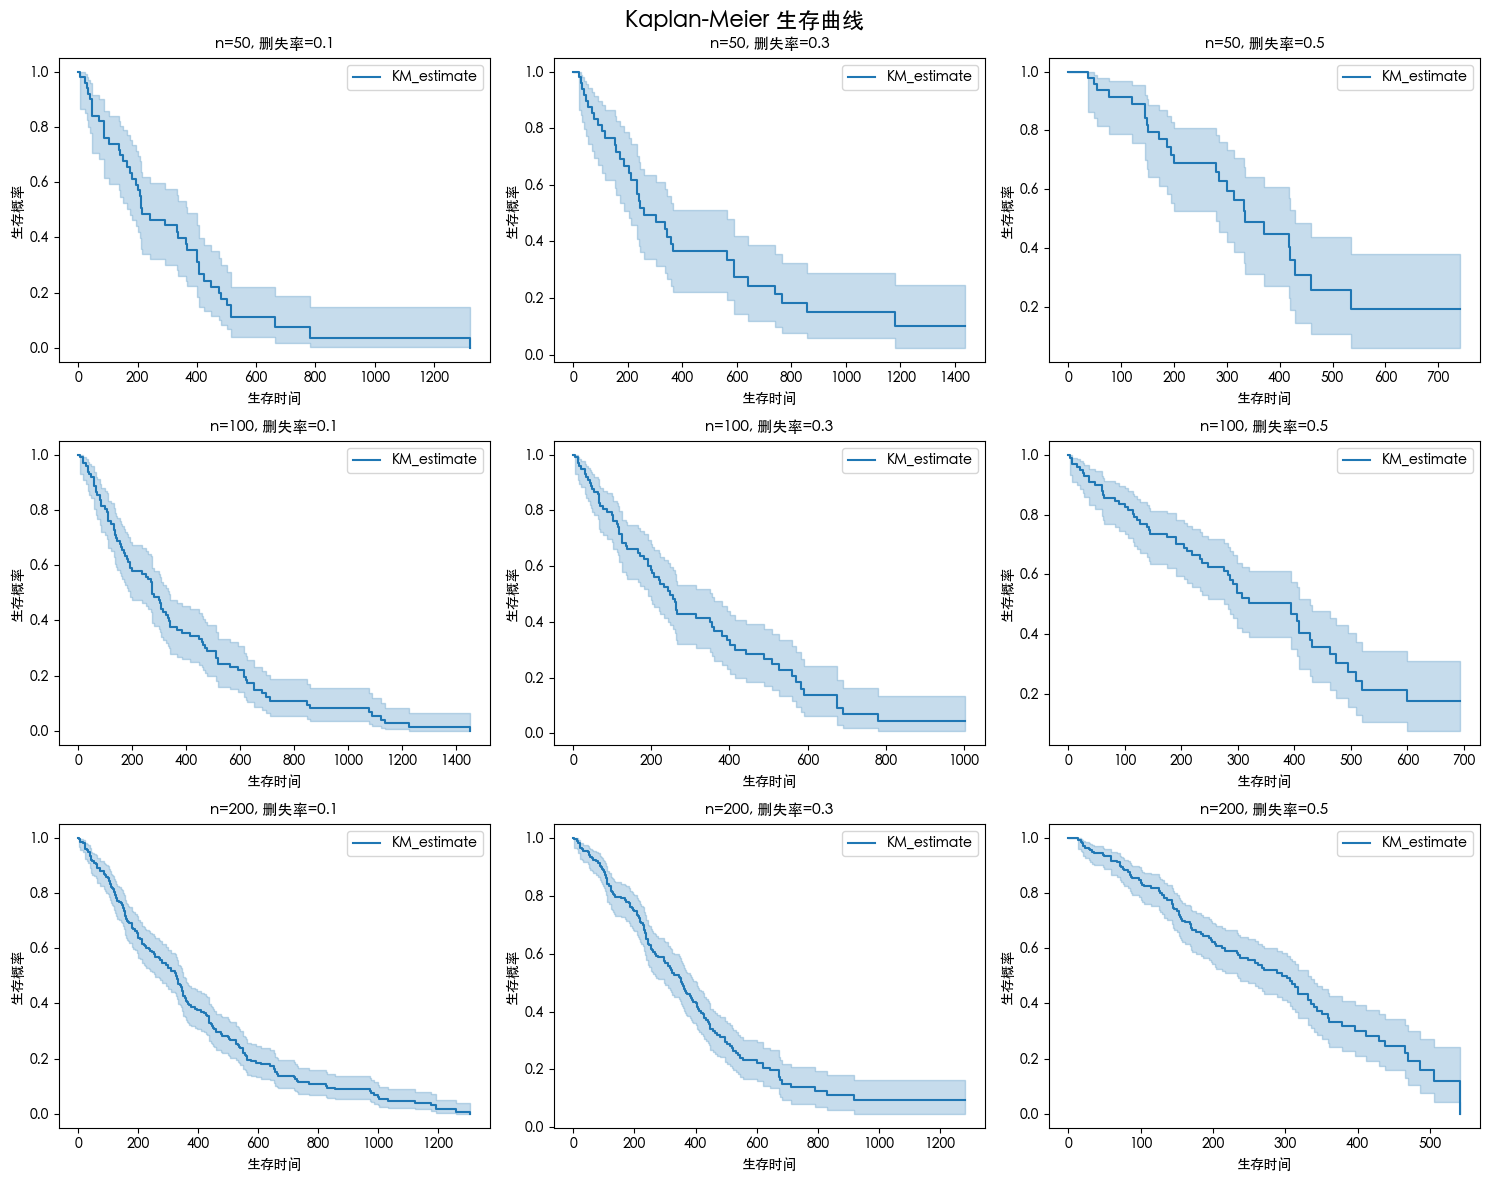

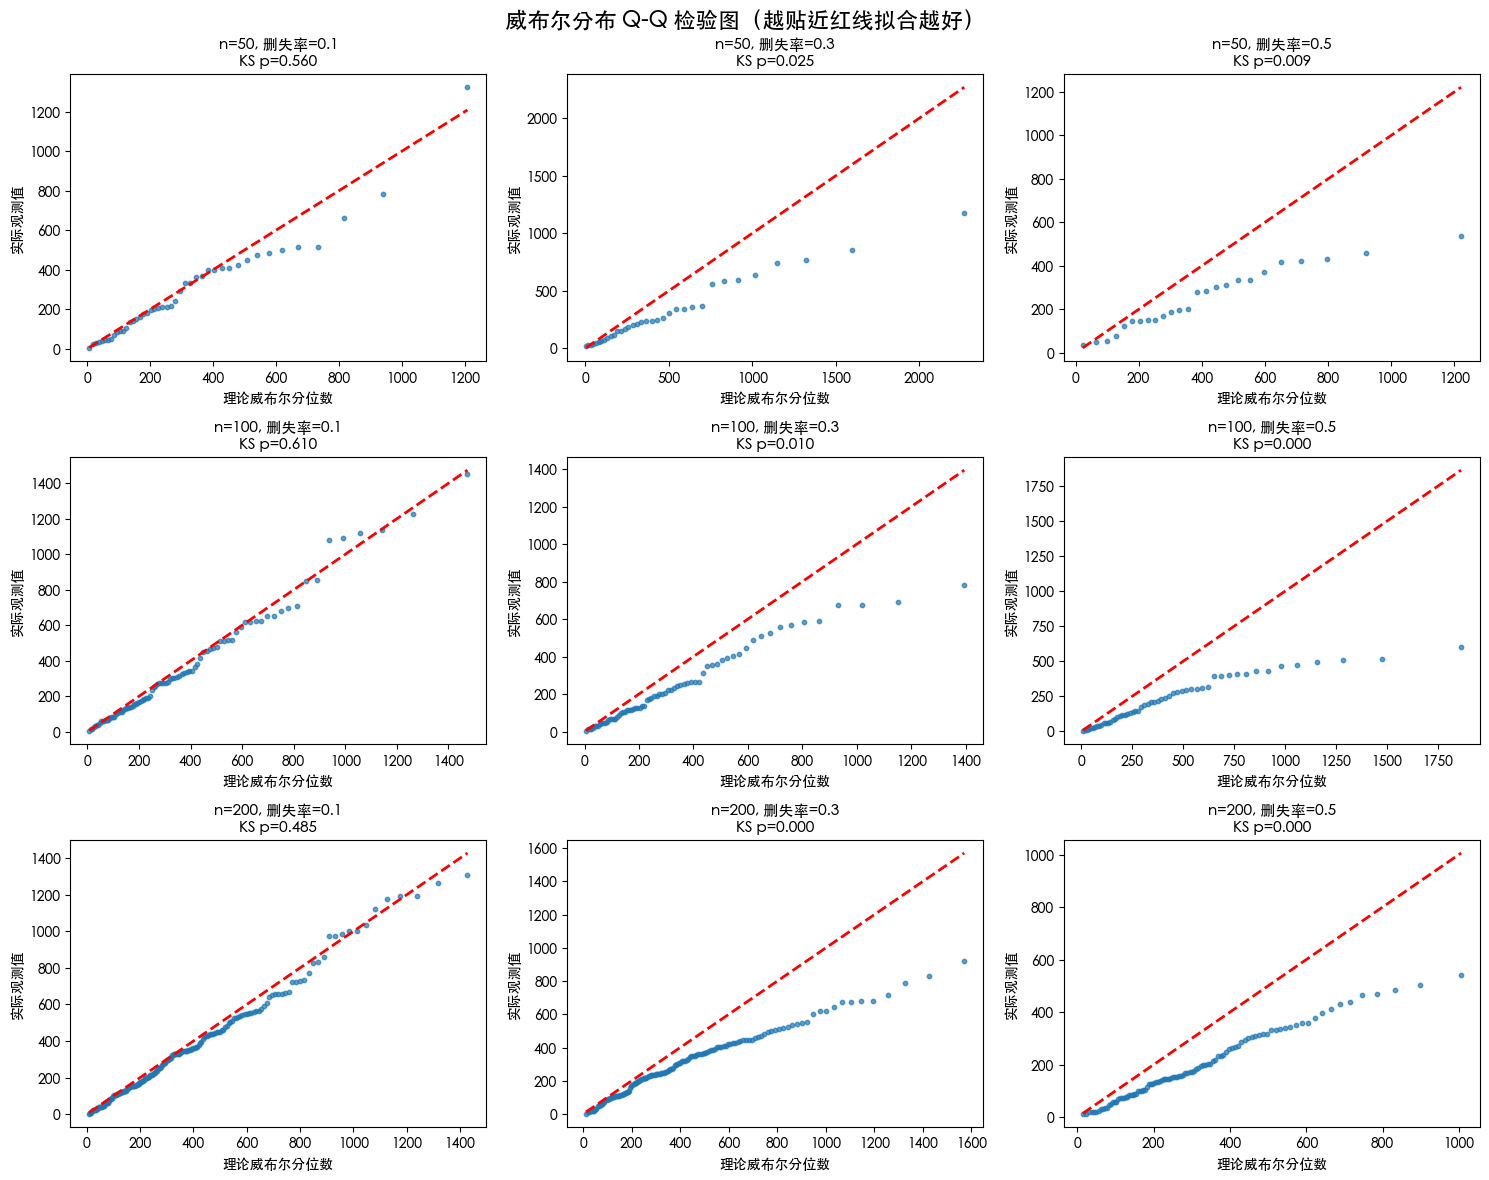

=== 样本量50_删失率0.1 模型拟合结果 ===

【Cox 模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 5 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 45
   partial log-likelihood = -130.515
         time fit was run = 2026-03-28 13:14:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       0.039     1.040     0.018           0.003           0.075               1.003               1.078
gender    0.693     1.999     0.317           0.072           1.314               1.074               3.721

           cmp to     z     p  -log2(p)
covariate                              
age         0.000 2.144 0.032     4.966
gender      0.000 2.186 0.029     5.119
---
Concordance = 0.614
Partial AIC = 265.031
log-likelihood ratio test = 9.347 on 2 df
-log2(p) of ll-ratio test = 6.743


【威布尔模型参数】
形状参数 ρ: 1.168
尺度参数 λ: 326.728

【威布尔分布拟合优度检验（KS检验）】
KS 统计量: 0.1143
P 值: 0.5597
结论：**不拒绝威布尔分布假设**（拟合良好）


=== 样本量50_删失率0.3 模型拟合结果 ===

【Cox 模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 15 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 35
   partial log-likelihood = -106.362
         time fit was run = 2026-03-28 13:14:57 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age       -0.028     0.972     0.023          -0.073           0.017               0.929               1.017
gender    -0.413     0.662     0.363          -1.125           0.299               0.325               1.349

           cmp to      z     p  -log2(p)
covariate                               
age         0.000 -1.210 0.226     2.144
gender      0.000 -1.137 0.256     1.968
---
Concordance = 0.593
Partial AIC = 216.724
log-likelihood ratio test = 2.033 on 2 df
-log2(p) of ll-ratio test = 1.467


【威布尔模型参数】
形状参数 ρ: 0.993
尺度参数 λ: 487.225

【威布尔分布拟合优度检验（KS检验）】
KS 统计量: 0.2444
P 值: 0.0251
结论：**拒绝威布尔分布假设**（拟合不佳）


=== 样本量50_删失率0.5 模型拟合结果 ===

【Cox 模型摘要】


...


【威布尔模型参数】
形状参数 ρ: 1.219
尺度参数 λ: 407.969

【威布尔分布拟合优度检验（KS检验）】
KS 统计量: 0.0615
P 值: 0.4851
结论：**不拒绝威布尔分布假设**（拟合良好）


=== 样本量200_删失率0.3 模型拟合结果 ===

【Cox 模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -627.926
         time fit was run = 2026-03-28 13:14:57 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.013     1.013     0.009          -0.005           0.030               0.995               1.030
gender    -0.099     0.905     0.169          -0.431           0.232               0.650               1.262

           cmp to      z     p  -log2(p)
covariate                               
age         0.000  1.423 0.155     2.691
gender      0.000 -0.587 0.557     0.844
---
Concordance = 0.521
Partial AIC = 1259.852
log-likelihood ratio test = 2.325 on 2 df
-log2(p) of ll-ratio test = 1.677


【威布尔模型参数】
形状参数 ρ: 1.257
尺度参数 λ: 466.142

【威布尔分布拟合优度检验（KS检验）】
KS 统计量: 0.2036
P 值: 0.0000
结论：**拒绝威布尔分布假设**（拟合不佳）


=== 样本量200_删失率0.5 模型拟合结果 ===

【Cox 模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 100 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 100
   partial log-likelihood = -433.617
         time fit was run = 2026-03-28 13:14:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       0.008     1.008     0.011          -0.013           0.029               0.987               1.029
gender    0.219     1.244     0.203          -0.179           0.616               0.836               1.852

           cmp to     z     p  -log2(p)
covariate                              
age         0.000 0.748 0.454     1.139
gender      0.000 1.078 0.281     1.830
---
Concordance = 0.552
Partial AIC = 871.233
log-likelihood ratio test = 1.726 on 2 df
-log2(p) of ll-ratio test = 1.245


【威布尔模型参数】
形状参数 ρ: 1.437
尺度参数 λ: 347.621

【威布尔分布拟合优度检验（KS检验）】
KS 统计量: 0.2683
P 值: 0.0000
结论：**拒绝威布尔分布假设**（拟合不佳）




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullFitter
from scipy.stats import kstest, weibull_min

# 防止乱码
plt.rcParams["font.family"] = ["Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

# 三大生存模型拟合
model_results = {}

for (n, cp), data in sim_data_dict.items():
    df = data.copy()
    key = f"样本量{n}_删失率{cp}"
    
    # 1. Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(data["survival_time"], event_observed=data["event"])
    km_model = kmf
    
    # 2. Cox
    cph = CoxPHFitter()
    cph.fit(df, duration_col="survival_time", event_col="event")
    cox_model = cph
    
    # 3. 威布尔（加微小量避免0）
    wbf = WeibullFitter()
    t = df["survival_time"] + 1e-6
    wbf.fit(t, df["event"])
    weibull_model = wbf

    #  威布尔分布检验 
    event_data = df[df["event"] == 1]["survival_time"] + 1e-6
    lam = weibull_model.lambda_  # 尺度参数
    rho = weibull_model.rho_     # 形状参数

    # KS 检验
    ks_stat, ks_p = kstest(
        event_data,
        "weibull_min",
        args=(rho, 0, lam)
    )

    # 保存检验结果
    model_results[key] = {
        "km": km_model,
        "cox": cox_model,
        "weibull": weibull_model,
        "weibull_test": {
            "event_data": event_data,
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "lambda_": lam,
            "rho_": rho
        }
    }

# 1. 绘制 KM 生存曲线 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for idx, ((n, cp), data) in enumerate(sim_data_dict.items()):
    ax = axes[idx]
    key = f"样本量{n}_删失率{cp}"
    kmf = model_results[key]["km"]
    kmf.plot_survival_function(ax=ax)
    ax.set_title(f"n={n}, 删失率={cp}", fontsize=11)
    ax.set_xlabel("生存时间", fontsize=10)
    ax.set_ylabel("生存概率", fontsize=10)

fig.suptitle("Kaplan-Meier 生存曲线", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 2. 绘制威布尔 Q-Q 图（拟合检验）
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for idx, ((n, cp), data) in enumerate(sim_data_dict.items()):
    ax = axes[idx]
    key = f"样本量{n}_删失率{cp}"
    test_res = model_results[key]["weibull_test"]
    
    event_data = test_res["event_data"]
    rho = test_res["rho_"]
    lam = test_res["lambda_"]
    
    # 理论分位数 vs 实际分位数
    theoretical = weibull_min.ppf(np.linspace(0.01, 0.99, len(event_data)), rho, 0, lam)
    observed = np.sort(event_data)
    
    ax.scatter(theoretical, observed, s=10, alpha=0.7)
    # 对角线：越贴近 = 拟合越好
    ax.plot([theoretical.min(), theoretical.max()],
            [theoretical.min(), theoretical.max()], "r--", lw=2)
    
    ax.set_title(f"n={n}, 删失率={cp}\nKS p={test_res['ks_p']:.3f}", fontsize=11)
    ax.set_xlabel("理论威布尔分位数")
    ax.set_ylabel("实际观测值")

fig.suptitle("威布尔分布 Q-Q 检验图（越贴近红线拟合越好）", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# 3. 输出模型结果 + 威布尔检验 
for i in range(9):
    test_key = list(model_results.keys())[i]
    res = model_results[test_key]
    weibull_test = res["weibull_test"]
    
    print(f"=== {test_key} 模型拟合结果 ===")
    
    print("\n【Cox 模型摘要】")
    res["cox"].print_summary(decimals=3)
    
    print("\n【威布尔模型参数】")
    print(f"形状参数 ρ: {weibull_test['rho_']:.3f}")
    print(f"尺度参数 λ: {weibull_test['lambda_']:.3f}")
    
    print("\n【威布尔分布拟合优度检验（KS检验）】")
    print(f"KS 统计量: {weibull_test['ks_stat']:.4f}")
    print(f"P 值: {weibull_test['ks_p']:.4f}")
    if weibull_test['ks_p'] > 0.05:
        print("结论：**不拒绝威布尔分布假设**（拟合良好）")
    else:
        print("结论：**拒绝威布尔分布假设**（拟合不佳）")
    print("\n")

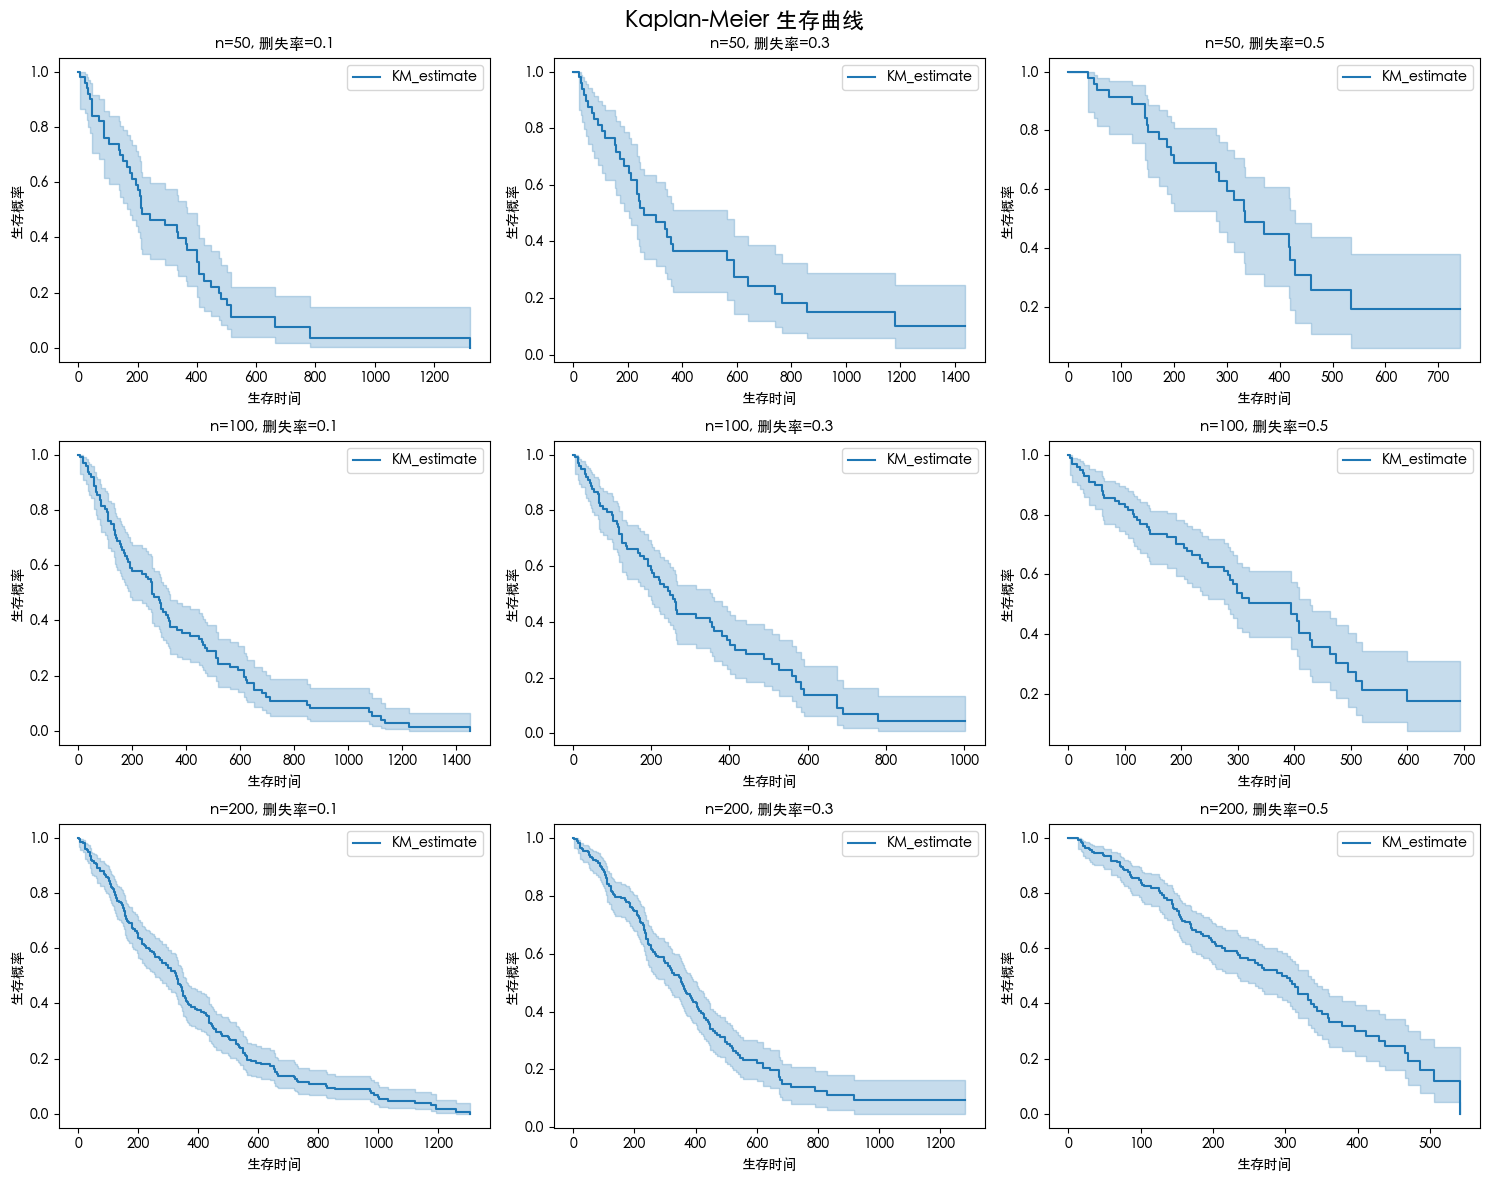

=== 样本量50_删失率0.1 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 5 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 45
   partial log-likelihood = -130.515
         time fit was run = 2026-03-28 12:53:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       0.039     1.040     0.018           0.003           0.075               1.003               1.078
gender    0.693     1.999     0.317           0.072           1.314               1.074               3.721

           cmp to     z     p  -log2(p)
covariate                              
age         0.000 2.144 0.032     4.966
gender      0.000 2.186 0.029     5.119
---
Concordance = 0.614
Partial AIC = 265.031
log-likelihood ratio test = 9.347 on 2 df
-log2(p) of ll-ratio test = 6.743


【威布尔模型参数】
形状参数λ: 326.728
尺度参数ρ: 1.168
=== 样本量50_删失率0.3 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 50 total observations, 15 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 50
number of events observed = 35
   partial log-likelihood = -106.362
         time fit was run = 2026-03-28 12:53:00 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age       -0.028     0.972     0.023          -0.073           0.017               0.929               1.017
gender    -0.413     0.662     0.363          -1.125           0.299               0.325               1.349

           cmp to      z     p  -log2(p)
covariate                               
age         0.000 -1.210 0.226     2.144
gender      0.000 -1.137 0.256     1.968
---
Concordance = 0.593
Partial AIC = 216.724
log-likelihood ratio test = 2.033 on 2 df
-log2(p) of ll-ratio test = 1.467


【威布尔模型参数】
形状参数λ: 487.225
尺度参数ρ: 0.993
=== 样本量50_删失率0.5 模型拟合结果 ===

【Cox模型摘要】


...


【威布尔模型参数】
形状参数λ: 407.969
尺度参数ρ: 1.219
=== 样本量200_删失率0.3 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -627.926
         time fit was run = 2026-03-28 12:53:00 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age        0.013     1.013     0.009          -0.005           0.030               0.995               1.030
gender    -0.099     0.905     0.169          -0.431           0.232               0.650               1.262

           cmp to      z     p  -log2(p)
covariate                               
age         0.000  1.423 0.155     2.691
gender      0.000 -0.587 0.557     0.844
---
Concordance = 0.521
Partial AIC = 1259.852
log-likelihood ratio test = 2.325 on 2 df
-log2(p) of ll-ratio test = 1.677


【威布尔模型参数】
形状参数λ: 466.142
尺度参数ρ: 1.257
=== 样本量200_删失率0.5 模型拟合结果 ===

【Cox模型摘要】


<lifelines.CoxPHFitter: fitted with 200 total observations, 100 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 100
   partial log-likelihood = -433.617
         time fit was run = 2026-03-28 12:53:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       0.008     1.008     0.011          -0.013           0.029               0.987               1.029
gender    0.219     1.244     0.203          -0.179           0.616               0.836               1.852

           cmp to     z     p  -log2(p)
covariate                              
age         0.000 0.748 0.454     1.139
gender      0.000 1.078 0.281     1.830
---
Concordance = 0.552
Partial AIC = 871.233
log-likelihood ratio test = 1.726 on 2 df
-log2(p) of ll-ratio test = 1.245


【威布尔模型参数】
形状参数λ: 347.621
尺度参数ρ: 1.437


In [4]:

# 防止乱码
plt.rcParams["font.family"] = [  "Heiti TC"] 
plt.rcParams["axes.unicode_minus"] = False 

# 三大生存模型拟合
model_results = {}  

for (n, cp), data in sim_data_dict.items():
    df = data.copy()
    key = f"样本量{n}_删失率{cp}"
    # 1. Kaplan-Meier 
    kmf = KaplanMeierFitter()
    kmf.fit(data["survival_time"], event_observed=data["event"])
    km_model = kmf
    # 2. Cox 
    cph = CoxPHFitter()
    cph.fit(df, duration_col="survival_time", event_col="event")
    cox_model = cph
    # 3. 威布尔
    wbf = WeibullFitter()
    wbf.fit(df["survival_time"] + 1e-6, df["event"])
    weibull_model = wbf

    model_results[key] = {
        "km": km_model,
        "cox": cox_model,
        "weibull": weibull_model
    }
# 绘图
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12)) 
axes = axes.flatten()  
for idx, ((n, cp), data) in enumerate(sim_data_dict.items()):
    ax = axes[idx]  
    
    # 拟合 Kaplan-Meier 模型
    kmf = model_results[f"样本量{n}_删失率{cp}"]["km"]    # 绘制生存曲线
    kmf.plot_survival_function(ax=ax)
    ax.set_title(f"n={n}, 删失率={cp}", fontsize=11)
    ax.set_xlabel("生存时间", fontsize=10)
    ax.set_ylabel("生存概率", fontsize=10)

fig.suptitle("Kaplan-Meier 生存曲线", fontsize=16, y=0.98)  # 总标题
plt.tight_layout()
plt.show()

# 输出模型摘要（验证拟合成功）
for i in range(9):
    test_key = list(model_results.keys())[i]
    print(f"=== {test_key} 模型拟合结果 ===")
    print("\n【Cox模型摘要】")
    model_results[test_key]["cox"].print_summary(decimals=3)
    print("\n【威布尔模型参数】")
    print(f"形状参数λ: {model_results[test_key]['weibull'].lambda_:.3f}")
    print(f"尺度参数ρ: {model_results[test_key]['weibull'].rho_:.3f}")